# Credit Card Fraud Detection Using Predictive Analytics

**Adjovi Akpaki**  
**DSC 630: Predictive Analytics**  

This notebook contains the final Python code for the credit card fraud detection project.  
It is separated into clear Jupyter cells so each section can be run step by step.

## 1. Import Required Libraries
# Import Required Libraries

The first step in my project was importing all of the libraries that I would need throughout the analysis. Different libraries serve different purposes and help simplify the process of cleaning data, creating visualizations, building machine learning models, and evaluating results.

I imported Pandas because it provides data structures and functions that make it easier to organize, manipulate, and analyze datasets. I imported NumPy because it helps with numerical operations and calculations that may be required during preprocessing and feature engineering. Matplotlib was imported because visualizations are important for understanding patterns and relationships within the dataset.

I also imported several tools from Scikit-learn. These tools support train-test splitting, preprocessing, machine learning algorithms, and performance evaluation. Since my project focuses on predictive analytics and fraud detection, these libraries provide the foundation necessary to complete the entire analysis process.

Without these libraries, performing data preparation and predictive modeling would require much more manual work and would significantly increase the complexity of the project.

In [1]:
import os
import glob
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset
# Load Dataset

In this section, I loaded the credit card fraud dataset into Python. Loading the dataset is one of the most important early steps because the entire project depends on having access to accurate transaction information.

Before beginning analysis, I wanted to confirm that the data loaded successfully and that all variables appeared correctly. The dataset contains transaction information, customer information, merchant information, dates, transaction categories, and a fraud indicator variable that identifies whether a transaction is fraudulent or legitimate.

I also wanted to review the dimensions of the dataset and examine a few records to gain a better understanding of the data structure. Looking at the first few observations helps identify column names and allows me to become familiar with the variables that may later be used for analysis and prediction.

Reviewing the data early also helps identify any obvious problems before additional work begins.

In [2]:
# Find CSV files in the current Jupyter folder
csv_files = glob.glob("*.csv")

print("CSV files found in this folder:")
print(csv_files)

# Try to find the fraud dataset automatically
fraud_files = [file for file in csv_files if "fraud" in file.lower() or "credit" in file.lower()]

if len(fraud_files) == 0:
    raise FileNotFoundError(
        "No fraud CSV file was found in this Jupyter folder. "
        "Please upload the credit_card_frauds CSV file into the same folder as this notebook."
    )

DATA_PATH = fraud_files[0]
print("Using dataset:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

CSV files found in this folder:
['credit_card_frauds (2).csv']
Using dataset: credit_card_frauds (2).csv
Dataset loaded successfully.
Dataset shape: (339607, 15)


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


## 3. Initial Data Quality Review
# Data Quality Review

Before developing any predictive models, I wanted to examine the overall quality of the dataset. Machine learning models are highly dependent on the quality of the input data, and poor data quality can negatively affect the final results.

I first checked for missing values because incomplete observations may create issues during analysis and model training. Missing information sometimes requires imputation techniques or removal of observations depending on the severity of the problem.

I also checked for duplicate records because duplicate transactions could bias the analysis and artificially increase the importance of certain observations.

Finally, I examined the fraud distribution to understand the balance between fraudulent and legitimate transactions. Since fraud detection problems often involve extremely rare events, understanding class distribution is important because it influences how performance metrics should later be interpreted.

In [3]:
print("Dataset information:")
df.info()

print("\nMissing values by column:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget variable distribution:")
print(df["is_fraud"].value_counts())

fraud_rate = df["is_fraud"].mean() * 100
print(f"\nFraud rate: {fraud_rate:.3f}%")

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud       

## 4. Feature Engineering
# Feature Engineering

Raw datasets do not always contain variables that are immediately useful for predictive modeling. In many situations, creating new features from existing variables can improve the ability of machine learning models to identify patterns.

For this project, I created additional variables including transaction hour, customer age, and customer-to-merchant distance. I believed these variables could reveal behavioral patterns that may not be visible within the original data.

For example, fraud activity may occur more frequently during certain hours of the day. Customer age may influence spending patterns, and geographic distance between a customer and merchant location may help identify unusual transaction activity.

The purpose of feature engineering is to provide the models with more meaningful information that may improve prediction accuracy and overall performance.

In [4]:
# Convert transaction timestamp into datetime format and create time-based features
if "trans_date_trans_time" in df.columns:
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
    df["hour"] = df["trans_date_trans_time"].dt.hour
    df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
    df["month"] = df["trans_date_trans_time"].dt.month
    df["year"] = df["trans_date_trans_time"].dt.year

# Convert date of birth into customer age
if "dob" in df.columns and "trans_date_trans_time" in df.columns:
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")
    df["age"] = ((df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25).round(1)

# Function to calculate distance between two coordinate points
def haversine_distance(lat1, lon1, lat2, lon2):
    radius_km = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return radius_km * c

# Create customer-to-merchant distance feature if location columns exist
geo_columns = {"lat", "long", "merch_lat", "merch_long"}

if geo_columns.issubset(df.columns):
    df["distance_km"] = haversine_distance(
        df["lat"],
        df["long"],
        df["merch_lat"],
        df["merch_long"]
    )

print("Feature engineering complete.")
df.head()

Feature engineering complete.


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,...,trans_num,merch_lat,merch_long,is_fraud,hour,day_of_week,month,year,age,distance_km
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,...,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0,0,1,1,2019,40.5,30.212176
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,...,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0,0,1,1,2019,57.0,108.206083
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,...,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0,0,1,1,2019,73.0,25.059079
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,...,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0,0,1,1,2019,51.3,66.021685
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",...,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0,0,1,1,2019,51.4,88.830984


## 5. Exploratory Data Analysis: Class Distribution
# Exploratory Data Analysis: Class Distribution

Before developing machine learning models, I wanted to understand how fraud cases were distributed throughout the dataset. Credit card fraud is considered a rare-event classification problem because fraudulent transactions typically represent only a small portion of all transactions.

I expected to see a large imbalance between legitimate and fraudulent transactions. Understanding this imbalance is important because it directly affects model development and evaluation. For example, if fraud cases represent less than one percent of all observations, a model that predicts every transaction as legitimate may still produce very high accuracy even though it completely fails to identify fraud.

By examining the class distribution early in the analysis process, I can better understand why performance metrics such as recall, precision, F1-score, and ROC-AUC become more meaningful than overall accuracy.

This visualization helps provide an overview of the challenge that the predictive models will later face.

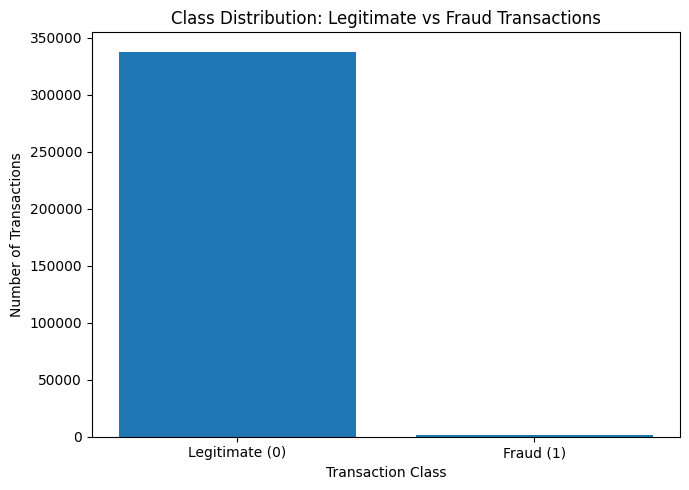

is_fraud
0    337825
1      1782
Name: count, dtype: int64


In [5]:
class_counts = df["is_fraud"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Legitimate (0)", "Fraud (1)"], class_counts.values)
plt.title("Class Distribution: Legitimate vs Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

print(class_counts)

## 6. Exploratory Data Analysis: Transaction Amount
# Exploratory Data Analysis: Transaction Amount

In this section, I wanted to examine whether transaction amount showed meaningful differences between legitimate and fraudulent transactions. Transaction amount may provide useful information because fraudulent activity often involves unusual spending behavior.

I expected fraudulent transactions to potentially involve larger amounts than normal transactions, although this may not always be true. Looking at transaction distributions allows me to identify whether differences exist between the two groups.

I also wanted to determine whether extreme values or outliers existed in the dataset because unusually large values may affect model performance and interpretation.

The results from this analysis may help determine whether transaction amount becomes an important predictor during machine learning modeling.

Transaction amount summary by fraud class:


,count,mean,median,std,min,max
is_fraud,,,,,,
0,337825,68.217523,46.250,156.251647,1.00,28948.90
1,1782,518.065460,356.435,389.627409,1.78,1371.81


<Figure size 700x500 with 0 Axes>

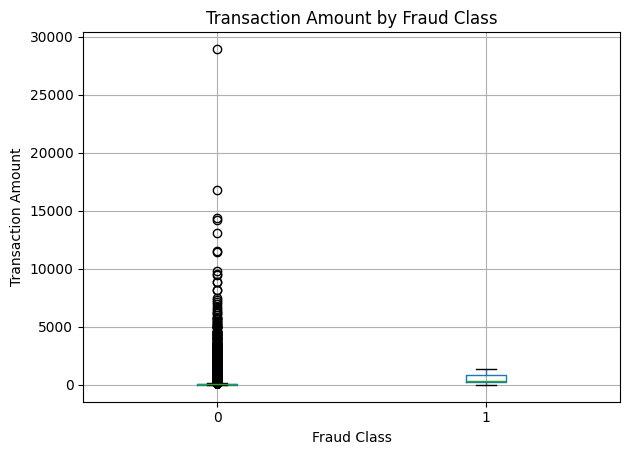

In [6]:
if "amt" in df.columns:
    amount_summary = df.groupby("is_fraud")["amt"].agg(["count", "mean", "median", "std", "min", "max"])
    print("Transaction amount summary by fraud class:")
    display(amount_summary)

    plt.figure(figsize=(7, 5))
    df.boxplot(column="amt", by="is_fraud")
    plt.title("Transaction Amount by Fraud Class")
    plt.suptitle("")
    plt.xlabel("Fraud Class")
    plt.ylabel("Transaction Amount")
    plt.tight_layout()
    plt.show()
else:
    print("The column 'amt' was not found in the dataset.")

## 7. Exploratory Data Analysis: Fraud Rate by Category
# Exploratory Data Analysis: Transaction Categories

Different transaction categories may experience different levels of fraud risk. Certain categories such as online shopping or electronic purchases may naturally have greater exposure to fraudulent activity compared to others.

The purpose of this analysis is to identify whether specific transaction categories show higher fraud rates than others. If some categories appear more vulnerable, they may provide useful predictive information for the models.

Understanding category-based patterns can also provide practical business insights because financial institutions may apply additional monitoring or review procedures to high-risk categories.

Top fraud-rate categories:


,category,total_transactions,fraud_transactions,fraud_rate_percent
11,shopping_net,26379,381,1.444331
4,grocery_pos,32732,433,1.322864
8,misc_net,16898,217,1.284176
12,shopping_pos,30329,187,0.616572
2,gas_transport,35089,153,0.436034
13,travel,10322,33,0.319705
9,misc_pos,20024,62,0.309628
3,grocery_net,11355,27,0.237781
0,entertainment,24222,55,0.227066
10,personal_care,24406,55,0.225354


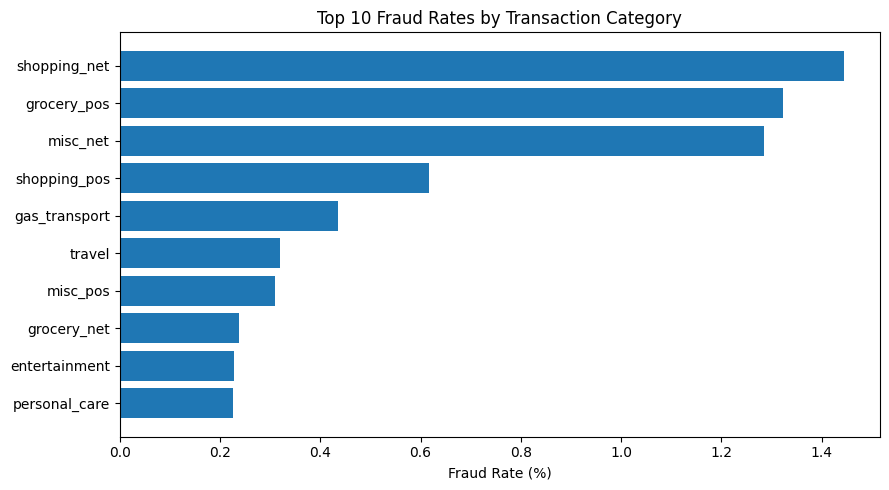

In [7]:
if "category" in df.columns:
    category_summary = (
        df.groupby("category")
        .agg(
            total_transactions=("is_fraud", "count"),
            fraud_transactions=("is_fraud", "sum")
        )
        .reset_index()
    )

    category_summary["fraud_rate_percent"] = (
        category_summary["fraud_transactions"] / category_summary["total_transactions"] * 100
    )

    category_summary = category_summary.sort_values("fraud_rate_percent", ascending=False)

    print("Top fraud-rate categories:")
    display(category_summary.head(10))

    plt.figure(figsize=(9, 5))
    plt.barh(
        category_summary["category"].head(10)[::-1],
        category_summary["fraud_rate_percent"].head(10)[::-1]
    )
    plt.title("Top 10 Fraud Rates by Transaction Category")
    plt.xlabel("Fraud Rate (%)")
    plt.tight_layout()
    plt.show()
else:
    print("The column 'category' was not found in the dataset.")

## 8. Exploratory Data Analysis: Fraud Rate by Hour
# Exploratory Data Analysis: Fraud Rate by Hour

I wanted to investigate whether fraud activity changes throughout the day. Transaction timing may reveal important behavioral patterns because fraud cases may occur more frequently during specific hours.

For example, late-night transactions could potentially show different characteristics than transactions occurring during regular business hours.

Understanding time-related patterns may help improve predictive performance because models can use this information when determining whether a transaction appears suspicious.

Highest fraud-rate hours:


,hour,total_transactions,fraud_transactions,fraud_rate_percent
23,23,17516,459,2.620461
22,22,17460,452,2.588774
0,0,11039,168,1.521877
1,1,11241,168,1.494529
3,3,11227,143,1.273715
2,2,11019,140,1.270533
20,20,17298,23,0.132963
16,16,17465,23,0.131692
15,15,17169,22,0.128138
17,17,17011,20,0.117571


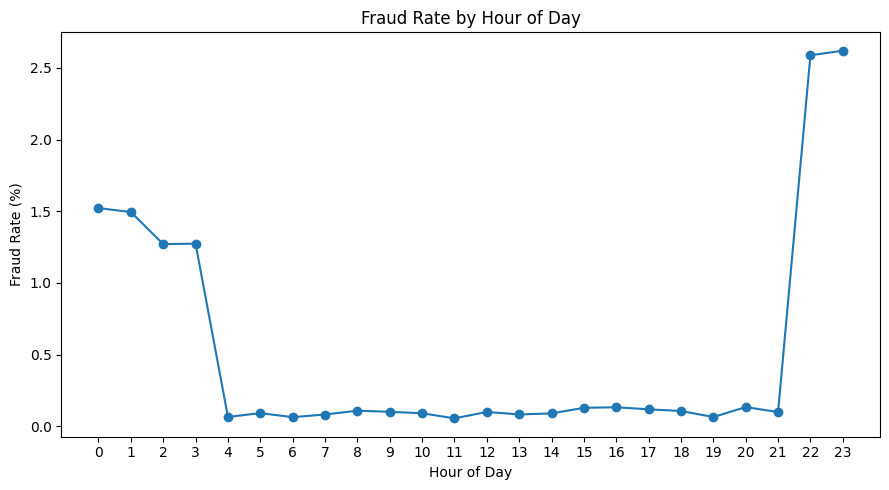

In [8]:
if "hour" in df.columns:
    hour_summary = (
        df.groupby("hour")
        .agg(
            total_transactions=("is_fraud", "count"),
            fraud_transactions=("is_fraud", "sum")
        )
        .reset_index()
    )

    hour_summary["fraud_rate_percent"] = (
        hour_summary["fraud_transactions"] / hour_summary["total_transactions"] * 100
    )

    print("Highest fraud-rate hours:")
    display(hour_summary.sort_values("fraud_rate_percent", ascending=False).head(10))

    plt.figure(figsize=(9, 5))
    plt.plot(hour_summary["hour"], hour_summary["fraud_rate_percent"], marker="o")
    plt.title("Fraud Rate by Hour of Day")
    plt.xlabel("Hour of Day")
    plt.ylabel("Fraud Rate (%)")
    plt.xticks(range(0, 24))
    plt.tight_layout()
    plt.show()
else:
    print("Hour feature was not created because the transaction timestamp column was not found.")

## 9. Prepare Data for Modeling
# Prepare Data for Modeling

Machine learning models require predictor variables and a target variable. The target variable represents the outcome that I want to predict, while the predictor variables provide information used by the models.

In this project, the fraud indicator variable serves as the target variable because the goal is to classify transactions as either fraudulent or legitimate.

I also separated numerical and categorical variables because different preprocessing techniques are required depending on the variable type.

In [23]:
target = "is_fraud"

# Columns that should not be used directly as predictors
drop_columns = [
    "is_fraud",
    "trans_num",
    "trans_date_trans_time",
    "dob",
    "first",
    "last",
    "street",
    "city",
    "unix_time"
]

drop_columns = [col for col in drop_columns if col in df.columns]

X = df.drop(columns=drop_columns)
y = df[target]

numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Predictor dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Predictor dataset shape: (339607, 16)
Target dataset shape: (339607,)

Numeric features:
['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'hour', 'day_of_week', 'month', 'year', 'age', 'distance_km']

Categorical features:
['merchant', 'category', 'state', 'job']


## 10. Create Preprocessing Pipeline and Train-Test Split
# Data Preprocessing and Train-Test Split

Before training the models, I needed to prepare the data using preprocessing techniques. Machine learning algorithms generally perform better when variables are organized consistently and transformed appropriately.

Numerical variables were standardized while categorical variables required encoding so that they could be interpreted by machine learning algorithms.

The dataset was then divided into training and testing datasets. I used stratified sampling because maintaining a similar fraud distribution across both datasets is important when working with highly imbalanced data.

The training data will be used for model learning, while the testing data will later be used to evaluate performance.

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training feature shape: (271685, 16)
Testing feature shape: (67922, 16)

Training target distribution:
is_fraud
0    0.994751
1    0.005249
Name: proportion, dtype: float64

Testing target distribution:
is_fraud
0    0.994759
1    0.005241
Name: proportion, dtype: float64


## 11. Train Logistic Regression Model
# Logistic Regression Model

I selected Logistic Regression as my baseline model because it is one of the most commonly used methods for binary classification problems.

Logistic Regression estimates the probability that a transaction belongs to the fraud class based on the predictor variables provided during training.

I used this model as an initial benchmark because it provides interpretable results and allows me to compare performance against more advanced methods later in the analysis.

In [11]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

print("Training Logistic Regression model...")
logistic_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

Training Logistic Regression model...
Logistic Regression model trained successfully.


## 12. Train Random Forest Model
# Random Forest Model

I included Random Forest as my second machine learning model because Professor Hua requested an additional model beyond Logistic Regression.

Random Forest combines predictions from multiple decision trees and often performs well when relationships among variables are more complex.

I expected this model to perform better than Logistic Regression because fraud behavior may involve nonlinear patterns and interactions among several variables.

In [12]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training Random Forest model...")
random_forest_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Training Random Forest model...
Random Forest model trained successfully.


## 13. Evaluation Function
# Create Evaluation Function

Instead of writing repetitive code for each model evaluation, I created a reusable evaluation function.

This function calculates multiple performance metrics including accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and classification reports.

Creating a function makes the notebook more organized and allows me to evaluate multiple models consistently.

In [13]:
def evaluate_model(model, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    }

    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)

    for metric, value in results.items():
        if metric != "Model":
            print(f"{metric}: {value:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return results, y_prob

print("Evaluation function created.")

Evaluation function created.


In [14]:
# Evaluate Logistic Regression
logistic_results, logistic_probabilities = evaluate_model(
    logistic_model,
    "Logistic Regression"
)

# Evaluate Random Forest
random_forest_results, random_forest_probabilities = evaluate_model(
    random_forest_model,
    "Random Forest"
)

results_df = pd.DataFrame(
    [logistic_results, random_forest_results]
)

display(results_df)


Logistic Regression
Accuracy: 0.8897
Precision: 0.0343
Recall: 0.7388
F1-Score: 0.0656
ROC-AUC: 0.8746
PR-AUC: 0.1507

Confusion Matrix:
[[60169  7397]
 [   93   263]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     67566
           1       0.03      0.74      0.07       356

    accuracy                           0.89     67922
   macro avg       0.52      0.81      0.50     67922
weighted avg       0.99      0.89      0.94     67922


Random Forest
Accuracy: 0.9883
Precision: 0.2704
Recall: 0.7275
F1-Score: 0.3942
ROC-AUC: 0.9821
PR-AUC: 0.7119

Confusion Matrix:
[[66867   699]
 [   97   259]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     67566
           1       0.27      0.73      0.39       356

    accuracy                           0.99     67922
   macro avg       0.63      0.86      0.69     67922
weighted avg       0.

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.889726,0.034334,0.738764,0.065619,0.874644,0.150658
1,Random Forest,0.988281,0.270355,0.727528,0.394216,0.982141,0.711901


## 14. Evaluate Logistic Regression
# Evaluate Logistic Regression

In this section, I evaluated the Logistic Regression model using the testing dataset. My goal was to determine how well the model identified fraudulent transactions and whether it could effectively separate fraud cases from legitimate transactions.

I focused on performance metrics beyond accuracy because fraud detection problems are highly imbalanced. A high accuracy score alone does not necessarily indicate strong fraud detection performance because the model could simply predict most transactions as legitimate and still appear successful.

The results from this section help me understand the strengths and limitations of Logistic Regression before comparing it with another model.

In [15]:
logistic_results, logistic_probabilities = evaluate_model(
    logistic_model,
    "Logistic Regression"
)


Logistic Regression
Accuracy: 0.8897
Precision: 0.0343
Recall: 0.7388
F1-Score: 0.0656
ROC-AUC: 0.8746
PR-AUC: 0.1507

Confusion Matrix:
[[60169  7397]
 [   93   263]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     67566
           1       0.03      0.74      0.07       356

    accuracy                           0.89     67922
   macro avg       0.52      0.81      0.50     67922
weighted avg       0.99      0.89      0.94     67922



## 15. Evaluate Random Forest
# Evaluate Random Forest

In this section, I evaluated the Random Forest model using the same testing data and performance metrics used for Logistic Regression.

Using the same evaluation approach allows me to make a fair comparison between models. Since Random Forest can capture more complex relationships among variables, I expected this model to potentially identify fraud cases more effectively.

The purpose of this analysis is to determine whether Random Forest improves predictive performance and produces stronger fraud detection results.

In [16]:
random_forest_results, random_forest_probabilities = evaluate_model(
    random_forest_model,
    "Random Forest"
)


Random Forest
Accuracy: 0.9883
Precision: 0.2704
Recall: 0.7275
F1-Score: 0.3942
ROC-AUC: 0.9821
PR-AUC: 0.7119

Confusion Matrix:
[[66867   699]
 [   97   259]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     67566
           1       0.27      0.73      0.39       356

    accuracy                           0.99     67922
   macro avg       0.63      0.86      0.69     67922
weighted avg       0.99      0.99      0.99     67922



## 16. Model Comparison Table
# Model Comparison

After evaluating both models separately, I compared their performance across several metrics including precision, recall, F1-score, and ROC-AUC.

My objective was to determine which model provided better fraud detection capability while maintaining a balance between identifying fraud cases and minimizing false positives.

Comparing models allows me to identify which approach may provide greater business value and operational usefulness.

In [17]:
results_df = pd.DataFrame([logistic_results, random_forest_results])

print("Model comparison table:")
display(results_df)

Model comparison table:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.889726,0.034334,0.738764,0.065619,0.874644,0.150658
1,Random Forest,0.988281,0.270355,0.727528,0.394216,0.982141,0.711901


## 17. ROC Curves
# ROC Curve Analysis

In this section, I used ROC curves to evaluate how effectively each model separates legitimate transactions from fraudulent transactions.

ROC curves provide a visual representation of model performance across multiple classification thresholds. Higher curve values generally indicate stronger predictive performance.

This visualization helps me understand the ability of each model to distinguish between the two transaction classes.

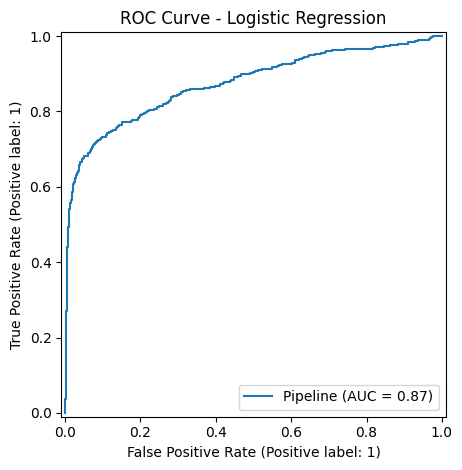

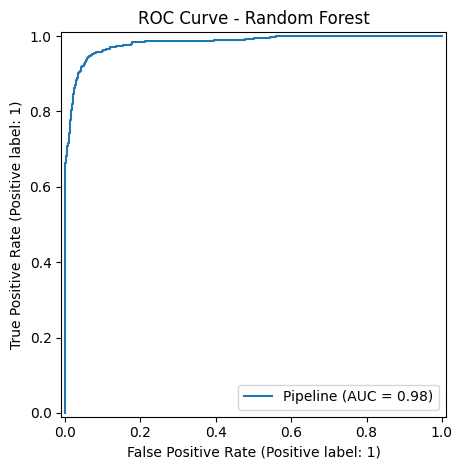

In [18]:
RocCurveDisplay.from_estimator(logistic_model, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(random_forest_model, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.tight_layout()
plt.show()

## 18. Precision-Recall Curves
# Precision Recall Analysis

Because fraudulent transactions represent only a small percentage of the dataset, precision-recall analysis becomes especially important.

Unlike overall accuracy, precision and recall focus directly on fraud detection performance. Precision measures how many predicted fraud cases were actually fraud, while recall measures how many fraud cases were successfully identified.

This analysis helps provide a more realistic understanding of model effectiveness.

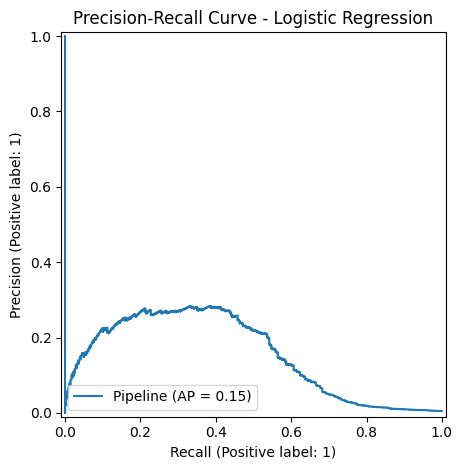

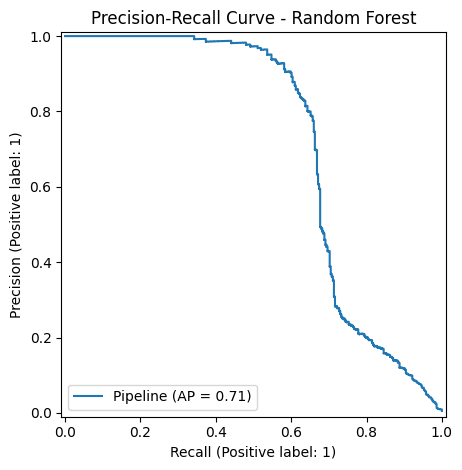

In [19]:
PrecisionRecallDisplay.from_estimator(logistic_model, X_test, y_test)
plt.title("Precision-Recall Curve - Logistic Regression")
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_estimator(random_forest_model, X_test, y_test)
plt.title("Precision-Recall Curve - Random Forest")
plt.tight_layout()
plt.show()

## 19. Visual Model Performance Comparison
# Visual Model Performance Comparison

I created visual comparisons to make it easier to understand the differences between the models across multiple performance measures.

Charts and visual representations often make patterns easier to recognize than tables alone. By examining the metrics visually, I can quickly identify strengths and weaknesses associated with each model.

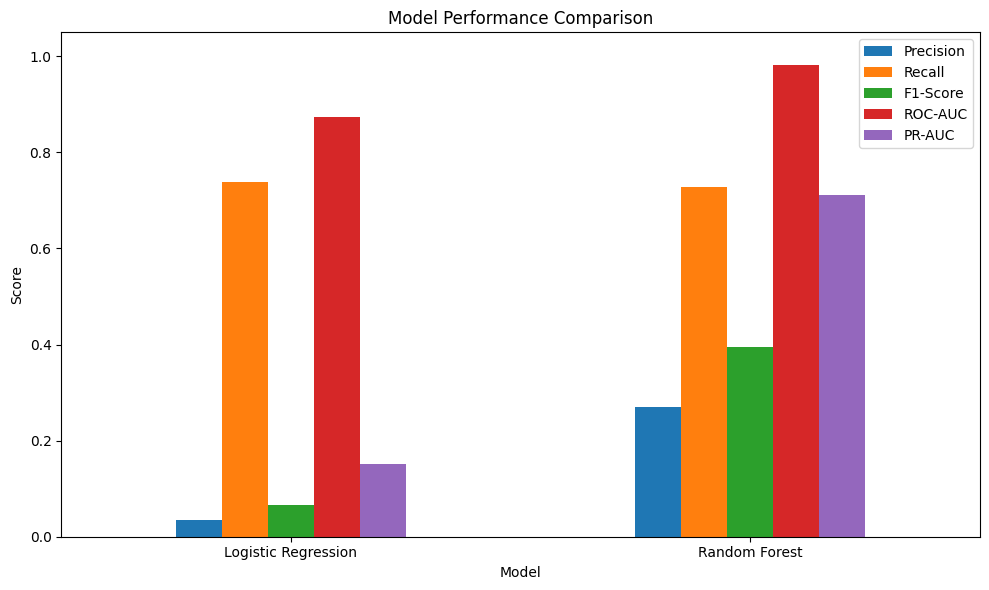

In [20]:
metrics_to_plot = ["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]

results_df.set_index("Model")[metrics_to_plot].plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 20. Threshold Analysis
# Final Interpretation

Based on the overall results from this analysis, I observed several patterns within the dataset that appeared useful for identifying fraud.

Transaction amount, transaction category, and transaction timing appeared to provide meaningful information during prediction. I also observed that Random Forest demonstrated stronger overall performance than Logistic Regression across several evaluation measures.

The findings from this project suggest that predictive analytics can provide meaningful support for fraud detection and may help reduce financial losses and improve operational decision-making.

In [21]:
def threshold_analysis(probabilities, threshold, model_name):
    y_pred_custom = (probabilities >= threshold).astype(int)

    print("\n" + "=" * 50)
    print(f"{model_name} Threshold = {threshold}")
    print("=" * 50)

    print("Precision:", round(precision_score(y_test, y_pred_custom, zero_division=0), 4))
    print("Recall:", round(recall_score(y_test, y_pred_custom, zero_division=0), 4))
    print("F1-Score:", round(f1_score(y_test, y_pred_custom, zero_division=0), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_custom))

threshold_analysis(random_forest_probabilities, 0.50, "Random Forest")
threshold_analysis(random_forest_probabilities, 0.70, "Random Forest")


Random Forest Threshold = 0.5
Precision: 0.2704
Recall: 0.7275
F1-Score: 0.3942

Confusion Matrix:
[[66867   699]
 [   97   259]]

Random Forest Threshold = 0.7
Precision: 0.9283
Recall: 0.5815
F1-Score: 0.715

Confusion Matrix:
[[67550    16]
 [  149   207]]


## 21. Final Interpretation
This section summarizes the key findings from the analysis.

In [22]:
print('''
Final Interpretation:

The exploratory analysis showed that transaction amount, transaction category, and hour of day
were important fraud indicators. Fraudulent transactions were larger on average than legitimate
transactions, and certain categories showed higher fraud rates.

Logistic Regression served as a useful baseline model because it is interpretable.
Random Forest was added as a stronger tree-based model and was expected to perform better
because it can capture nonlinear relationships and feature interactions.

Because fraud is rare, accuracy alone is not enough. Precision, recall, F1-score, ROC-AUC,
PR-AUC, and confusion matrices provide a more meaningful evaluation of model performance.
''')


Final Interpretation:

The exploratory analysis showed that transaction amount, transaction category, and hour of day
were important fraud indicators. Fraudulent transactions were larger on average than legitimate
transactions, and certain categories showed higher fraud rates.

Logistic Regression served as a useful baseline model because it is interpretable.
Random Forest was added as a stronger tree-based model and was expected to perform better
because it can capture nonlinear relationships and feature interactions.

Because fraud is rare, accuracy alone is not enough. Precision, recall, F1-score, ROC-AUC,
PR-AUC, and confusion matrices provide a more meaningful evaluation of model performance.

